# EDA 14 — Which of the ACS's 28,000 numbers can carry an error bar? A dataset-wide survey at county scale

**Question (lead-directed proof of concept, 2026-08-16):** everything this project has measured so far
(EDA 01–10) concerns a handful of hand-verified income & poverty variables. If the reliability tool is to
cover *more of the ACS*, we first need to know what the uncertainty landscape looks like across the whole
dataset: which subject areas publish usable error bars, which don't, how often the Bureau's special codes
replace real values, and whether the patterns we learned on income generalize. This is **report/EDA work
only** — no dashboard changes. *Scope note:* this survey is a deliberate, lead-approved exception to the
income-&-poverty scope fence (decision #14); mentor confirmation of the wider scope is queued as an open
question, not assumed. It speaks to **Q1** (where uncertainty enters), **Q3** (which published metrics are
fit for which uses), and **Q4** (how to communicate it).

**Plain-English setup.** Every ACS estimate is supposed to ship with a **margin of error (MOE)** — the
"± band" at 90% confidence. The **coefficient of variation (CV)** rescales that band by the estimate itself,

$$CV = \frac{MOE / 1.645}{estimate}$$

so a CV of 0.30 means the noise is about 30% the size of the thing measured (formula and citations in
[`analysis/acs.py`](../analysis/acs.py); terms in [`docs/glossary.md`](../docs/glossary.md)). But not every
published cell carries a real value: the Bureau substitutes **jam values** — giant negative sentinels like
`-666666666` — when an estimate can't be computed, and `-555555555` in the MOE slot when an estimate is
**controlled** to an official total and therefore has *no* sampling error at all. Same blank look, opposite
meanings. This survey counts all of it.

**Data.** Two files from one scripted pull (`python ingestion/pull_acs_wide_us_county.py`): a **manifest**
classifying all ~28,472 names in the 2024 `acs/acs5` variables.json (the *metadata census*), and estimate +
MOE + annotation values for a **deterministic stratified sample** of 100 detailed tables (~3,000 variables)
at **every US county** (~3,222, Puerto Rico's 78 municipios included and flagged). `acs/acs5` is the
*detailed tables* dataset — subject (S), data-profile (DP), and comparison-profile tables are separate API
datasets, out of this POC's scope. Ground truth: the New Jersey counties must reproduce our verified
income pull (`python ingestion/pull_acs_income_county_nj.py`) exactly.

**Expectation going in:** county scale is the ACS's *most* reliable geography, so CVs should mostly sit
below the descriptive 0.30 caution line — but the sample spans counties of ~60 people to 10 million, so
the size law (EDA 02) should spread every family across orders of magnitude, and detailed/small-subgroup
tables should still struggle. What we do not know is the *scoreability* mix: how much of the dataset's
surface is jam values, controlled estimates, and zeros rather than scoreable numbers.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs  # cv() and the citations behind it

RAW = REPO_ROOT / "data" / "raw"
PROCESSED = REPO_ROOT / "data" / "processed"


def load_parquet(name: str, regen: str) -> pd.DataFrame:
    path = RAW / name
    if not path.exists():
        raise FileNotFoundError(f"{path} -- regenerate with: python ingestion/{regen}")
    return pd.read_parquet(path)


PULL = "pull_acs_wide_us_county.py"
manifest = load_parquet("acswide_2024_variable_manifest.parquet", PULL)
long = load_parquet("acswide_2024_us_county_long.parquet", PULL)
geos = load_parquet("acswide_2024_us_county_geos.parquet", PULL)
report = load_parquet("acswide_2024_us_county_pull_report.parquet", PULL)

# category dtypes on the repeated keys keep ~10M rows at laptop scale
# (object dtype would roughly triple memory)
for col in ("geoid", "table_id", "variable"):
    if long[col].dtype.name != "category":
        long[col] = long[col].astype("category")

print(f"manifest {len(manifest):,} names | long {len(long):,} rows | "
      f"geos {len(geos):,} counties | report {len(report)} tables")

manifest 28,472 names | long 9,604,782 rows | geos 3,222 counties | report 100 tables


## 1. Data quality before analysis

House rule: sanity-check every dataset before analyzing it. The pull script already ran its own PASS/FAIL
battery; here we re-assert the shape facts every later section leans on, look at what failed, and take a
census of the **sentinel values** — because in this survey the special codes are not nuisance rows to drop,
they are part of the answer.

In [2]:
EXPECTED_NJ, EXPECTED_PR = 21, 78
FORCED = ["B01003", "B19013", "B17001", "C17002", "B01001B", "B19013B",
          "B25064", "B25077", "B15003", "B23025", "B27001"]

assert len(manifest) >= 28_000, (
    f"manifest has {len(manifest):,} names -- the variables.json census is incomplete")
assert 3140 <= len(geos) <= 3260, f"unexpected county count {len(geos):,}"
assert (geos["state"] == "72").sum() == EXPECTED_PR, "Puerto Rico municipio count changed"
assert (geos["state"] == "34").sum() == EXPECTED_NJ, "New Jersey county count changed"

ok = report[report["status"] == "ok"]
assert len(ok) / len(report) >= 0.90, (
    f"only {len(ok)}/{len(report)} tables pulled -- survey coverage is compromised")
missing_anchors = [t for t in FORCED if t not in set(ok["table_id"])]
assert not missing_anchors, f"forced anchor tables failed to pull: {missing_anchors}"

expected_rows = int((ok["n_e_vars"] * ok["n_rows"]).sum())
assert len(long) == expected_rows, (
    f"long file has {len(long):,} rows, expected {expected_rows:,} -- a table was "
    "partially ingested")

failed = report[report["status"] != "ok"]
print(f"{len(ok)}/{len(report)} tables ok; {long['variable'].nunique():,} variables; "
      f"every check above passed")
failed[["table_id", "status", "http_code", "error_msg"]] if len(failed) else print("no failed tables")

100/100 tables ok; 2,981 variables; every check above passed
no failed tables


**What the table says.** Coverage is complete: all 100 sampled tables returned every
one of the 3,222 counties (Puerto Rico's 78 municipios included), giving ~9.6 million county × variable
cells across 2,981 variables — and the failed-tables list is empty, so nothing below rests on a partial
table. The row-count identity (rows = Σ variables × counties, exactly) rules out silent truncation, the
lesson the team learned from the B98031 vacuous-check landmine: count what arrived, not just whether the
query succeeded.

In [3]:
# Official jam codes -- Census "Notes on ACS Estimate and Annotation Values"
# (verified against the live page 2026-08-16). Estimates and MOEs use
# different codes; the EA/MA columns carry the symbol form.
#
# Matching is NUMERIC, not string-exact: the API spells the same jam two
# ways depending on the variable's type -- integer variables return
# "-666666666" while float variables (median age etc.) return
# "-666666666.0". String matching silently misses the float form
# (found on this survey's first execution; ~3,900 cells).
JAM_E_MEANING = {-666666666: "- (not computable / open-ended median)",
                 -999999999: "N (too few sample cases)",
                 -888888888: "(X) not applicable"}
JAM_M_MEANING = {-555555555: "***** (controlled -- no sampling error)",
                 -222222222: "** (MOE not computable: insufficient sample)",
                 -333333333: "*** (MOE not computable: open-ended median)",
                 -999999999: "N (too few sample cases)",
                 -888888888: "(X) not applicable"}

est_code = pd.to_numeric(long["estimate_raw"], errors="coerce")
moe_code = pd.to_numeric(long["moe_raw"], errors="coerce")
est_jam = est_code.isin(JAM_E_MEANING)
moe_jam = moe_code.isin(JAM_M_MEANING)

census_rows = []
for code, meaning in JAM_E_MEANING.items():
    hit = est_code == code
    census_rows.append({
        "column": "estimate", "code": code, "meaning": meaning,
        "cells": int(hit.sum()),
        "integer_spelling": int((long["estimate_raw"] == str(code)).sum()),
        "float_spelling": int((long["estimate_raw"] == f"{code}.0").sum())})
for code, meaning in JAM_M_MEANING.items():
    hit = moe_code == code
    census_rows.append({
        "column": "MOE", "code": code, "meaning": meaning,
        "cells": int(hit.sum()),
        "integer_spelling": int((long["moe_raw"] == str(code)).sum()),
        "float_spelling": int((long["moe_raw"] == f"{code}.0").sum())})
sentinel_census = pd.DataFrame(census_rows)

# Direction 1 (hard): every jam value must carry its annotation symbol.
unannotated_e = int((est_jam & long["est_annot_raw"].isna()).sum())
unannotated_m = int((moe_jam & long["moe_annot_raw"].isna()).sum())
assert unannotated_e == 0, (
    f"{unannotated_e:,} jam-valued estimates carry no EA annotation -- "
    "the sentinel taxonomy is incomplete")
assert unannotated_m == 0, (
    f"{unannotated_m:,} jam-valued MOEs carry no MA annotation -- "
    "the sentinel taxonomy is incomplete")

# Direction 2 (locked after first execution): the ONLY annotations that sit
# on non-jam values are the Bureau's top/bottom-code markers on real median
# values ("250,000+", "2,500-", "1939-", "100+", "1-"). Anything new here
# means an annotation kind our taxonomy does not cover.
odd_e = long.loc[long["est_annot_raw"].notna() & ~est_jam, "est_annot_raw"].value_counts()
EDGE_MARKERS = {"250,000+", "2,500-", "1939-", "100+", "1-"}
unexpected = set(odd_e.index) - EDGE_MARKERS
assert not unexpected, (
    f"annotations on non-jam estimates beyond the known edge-code markers: "
    f"{unexpected} -- extend the taxonomy before trusting the classification")
print("edge-code markers on real median values:", dict(odd_e))
sentinel_census

edge-code markers on real median values: {'2,500-': np.int64(906), '250,000+': np.int64(384), '100+': np.int64(4), '1-': np.int64(4), '1939-': np.int64(4)}


,column,code,meaning,cells,integer_spelling,float_spelling
0,estimate,-666666666,- (not computable / open-ended median),51601,47737,3864
1,estimate,-999999999,N (too few sample cases),0,0,0
2,estimate,-888888888,(X) not applicable,0,0,0
3,MOE,-555555555,***** (controlled -- no sampling error),58911,58911,0
4,MOE,-222222222,** (MOE not computable: insufficient sample),51601,47737,3864
5,MOE,-333333333,*** (MOE not computable: open-ended median),1302,1294,8
6,MOE,-999999999,N (too few sample cases),0,0,0
7,MOE,-888888888,(X) not applicable,0,0,0


**What the table says.** Three findings, each invisible to a censusdis-based pull:

1. **The controlled sentinel is common and load-bearing.** ~58,900 MOE cells carry `-555555555` — real,
   *extremely reliable* estimates (pinned to official totals) whose blank-looking MOE means the opposite of
   unreliable. Nearly every county's total population is in this class.
2. **The same jam value is spelled two ways.** Integer-typed variables return `-666666666`; float-typed
   ones (median age and friends) return `-666666666.0`. A string-exact parser silently misses ~3,900 cells
   — ours matched numerically, and the two-spelling split is shown per code above. **Landmine for any
   future raw-API tooling.**
3. **The annotation columns carry the Bureau's top/bottom-code markers.** Every annotation that sits on a
   *real* value is an edge-code label — `250,000+` (earnings/income medians at their top code), `2,500-`
   (bottom code), `1939-` (median year built), `100+`/`1-` (median age edges) — with the MOE jammed as
   "open-ended median" (`-333333333`). That means top-code detection can be *empirical* (read the EA
   column) instead of hardcoding magic numbers per table, which is how EDA 01 had to do it for income.
   Both directions of the annotation⇄jam correspondence were verified empirically above.

In [4]:
# Every (estimate, MOE, EA, MA) tuple gets exactly ONE class, assigned in
# this precedence order (first match wins). Jam matching is numeric (see
# the sentinel census above).
#   1. estimate jam codes            -> est_* classes
#   2. MOE == -555555555             -> controlled (real value, NO sampling error)
#   3. estimate == 0                 -> zero_estimate (CV undefined, decision #5)
#   4. B19013* == 250,001            -> topcoded (censored, decision #6)
#   5. remaining MOE jam codes       -> moe_unavailable (mostly edge-coded medians)
#   6. everything blank, no annot    -> blank_unexplained (not published here)
#   7. estimate > 0 with real MOE    -> scoreable
#   8. residual                      -> other_blank_or_annotated
est_num = est_code.where(~est_jam)
moe_num = moe_code.where(~moe_jam)
is_b19013 = long["table_id"].astype(str).str.startswith("B19013")

cls = pd.Series(pd.NA, index=long.index, dtype="object")

def _set(mask, label):
    cls.loc[mask & cls.isna()] = label

_set(est_code == -666666666, "est_not_computable")
_set(est_code == -999999999, "est_too_few_cases")
_set(est_code == -888888888, "est_not_applicable")
_set(moe_code == -555555555, "controlled")
_set(est_num == 0, "zero_estimate")
_set(is_b19013 & (est_num == 250_001), "topcoded")
_set(moe_jam, "moe_unavailable")
_set(long["estimate_raw"].isna() & long["moe_raw"].isna()
     & long["est_annot_raw"].isna() & long["moe_annot_raw"].isna(),
     "blank_unexplained")
_set((est_num > 0) & (moe_num >= 0), "scoreable")
cls = cls.fillna("other_blank_or_annotated")

# CV only where it is legal (scoreable), via the project's shared formula.
cv = pd.Series(np.nan, index=long.index)
scoreable = cls == "scoreable"
cv[scoreable] = acs.cv(est_num[scoreable], moe_num[scoreable])

# Slim analysis frame; raw strings dropped to free memory.
var_meta = manifest[manifest["is_estimate"]].copy()
var_meta["variable"] = var_meta["name"].str[:-1]
maps = {c: var_meta.set_index("variable")[c]
        for c in ("family_code", "family_name", "measurement_type")}

df = pd.DataFrame({
    "geoid": long["geoid"].astype(str), "table_id": long["table_id"].astype(str),
    "variable": long["variable"].astype(str), "cell_class": pd.Categorical(cls),
    "estimate": est_num, "cv": cv,
})
df["is_pr"] = df["geoid"].str.startswith("72")
for c in ("family_code", "family_name", "measurement_type"):
    df[c] = pd.Categorical(df["variable"].map(maps[c]))
for c in ("geoid", "table_id", "variable"):
    df[c] = df[c].astype("category")
del long, cls, cv, est_code, moe_code, est_num, moe_num

class_counts = (df["cell_class"].value_counts().rename("cells").to_frame()
                .assign(share=lambda t: (t["cells"] / t["cells"].sum()).round(4)))
resid = int(class_counts["cells"].get("other_blank_or_annotated", 0))
assert resid / len(df) < 0.001, (
    f"{resid:,} cells fell into the residual class -- once jams are matched "
    "numerically it should be near-empty; something new is slipping through")
class_counts

,cells,share
cell_class,,
scoreable,6900292,0.7184
zero_estimate,1536149,0.1599
blank_unexplained,1056531,0.1100
controlled,58911,0.0061
est_not_computable,51601,0.0054
moe_unavailable,1294,0.0001
topcoded,4,0.0000


**What the table says.** About **72% of the sampled surface is scoreable** — a real
value with a real error bar. The rest is structured absence, each kind meaning something different: **16%
zero estimates** (CV undefined by decision #5 — "no Samoan-speaking 5-year-olds here" is information, not
noise), **11% published-but-blank** (silent nulls — whole tables that simply don't exist at county scale,
quantified in Section 3), **0.6% controlled** (the *most* reliable cells in the dataset), **~0.5% jammed**
as not-computable, and a sliver of edge-coded medians and top-codes. The design consequence: a reliability
layer that only computes CVs would misdescribe more than a quarter of the dataset's surface — the
unscoreable classes need their own words, which is precisely the Q4 communication problem.

## 2. What the ACS publishes — the metadata census

Before any data: what does the dataset's own catalog say it contains? All ~28,472 names, every table,
every subject family — classified by our manifest (the pull's first output). This is the complete surface;
the data sections that follow are the stratified sample of it.

Chart saved to data\processed\eda14_metadata_census.png (local-only, regenerable)


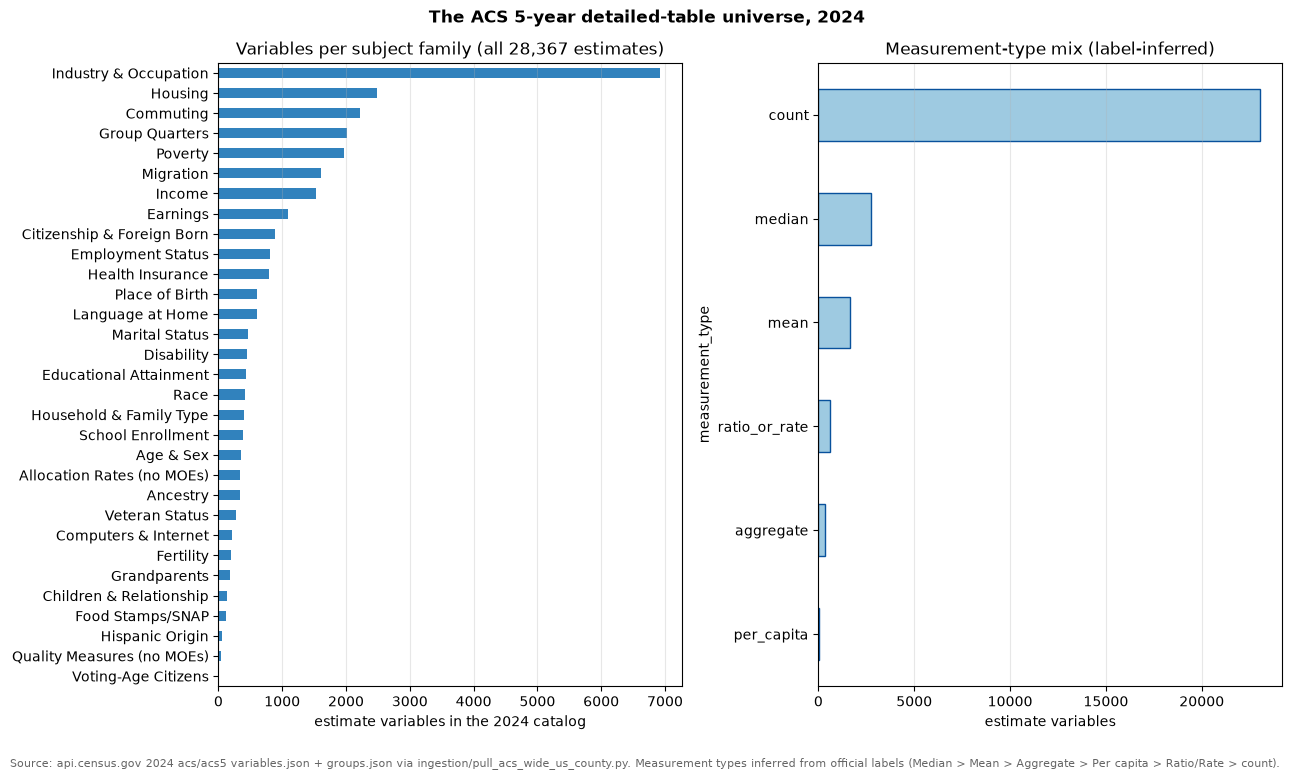

28,367 estimates in 1,177 tables; 2,745 medians (9.7%); 6,003 race/ethnicity-iteration variables (21.2%)


In [5]:
est_all = manifest[manifest["is_estimate"]]
fam = (est_all.groupby("family_name", observed=True)
       .agg(tables=("table_id", "nunique"), variables=("name", "size"))
       .sort_values("variables"))
type_mix = est_all["measurement_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))
fam["variables"].plot.barh(ax=axes[0], color="#3182bd")
axes[0].set_title(f"Variables per subject family (all {len(est_all):,} estimates)")
axes[0].set_xlabel("estimate variables in the 2024 catalog")
axes[0].set_ylabel("")
type_mix.sort_values().plot.barh(ax=axes[1], color="#9ecae1", edgecolor="#08519c")
axes[1].set_title("Measurement-type mix (label-inferred)")
axes[1].set_xlabel("estimate variables")
for ax in axes:
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("The ACS 5-year detailed-table universe, 2024", fontweight="bold")
fig.text(0.01, -0.03,
         "Source: api.census.gov 2024 acs/acs5 variables.json + groups.json via "
         "ingestion/pull_acs_wide_us_county.py. Measurement types inferred from official "
         "labels (Median > Mean > Aggregate > Per capita > Ratio/Rate > count).",
         fontsize=8, color="#666666")
fig.tight_layout()
out = PROCESSED / "eda14_metadata_census.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

n_median = int(type_mix.get("median", 0))
assert type_mix.get("count", 0) / type_mix.sum() > 0.5, (
    "counts should dominate the detailed tables -- classification looks wrong")
print(f"{len(est_all):,} estimates in {est_all['table_id'].nunique():,} tables; "
      f"{n_median:,} medians ({n_median / len(est_all):.1%}); "
      f"{int(est_all['is_iteration'].sum()):,} race/ethnicity-iteration variables "
      f"({est_all['is_iteration'].mean():.1%})")

**What the table says.** The catalog holds ~28,400 standard estimates in ~1,180
detailed tables across 31 families. **Counts dominate (~81%)** — good news for reliability tooling, because
counts are the type whose CV behavior is most predictable (Section 5). Medians are ~10% and need their own
handling (top/bottom codes, no universe in-table, the size-law escape). About a fifth of all variables are
**race/ethnicity iterations** (the A–I table suffixes) — structurally identical to their parents but with
much smaller universes, which is where small-subgroup noise concentrates (EDA 02's story, now visible as a
fifth of the catalog). One caveat carried from Phase 1: this manifest exists because we *derived* MOE names
by convention — the catalog itself advertises zero of them (the variables.json metadata gap, verified again
on this pull).

## 3. How much of the dataset can carry an error bar?

Now the sampled data. Each county × variable cell lands in exactly one class (Section 1's precedence).
"Scoreable" means a CV can legally be computed; **controlled** cells are *extremely reliable but unscoreable*
— the opposite of what their blank MOE suggests — and jam-valued cells are unreliable in a way no error bar
expresses. A reliability tool has to say all three things differently; lumping them is the mistake the
current published format invites.

Chart saved to data\processed\eda14_scoreability_by_family.png (local-only, regenerable)


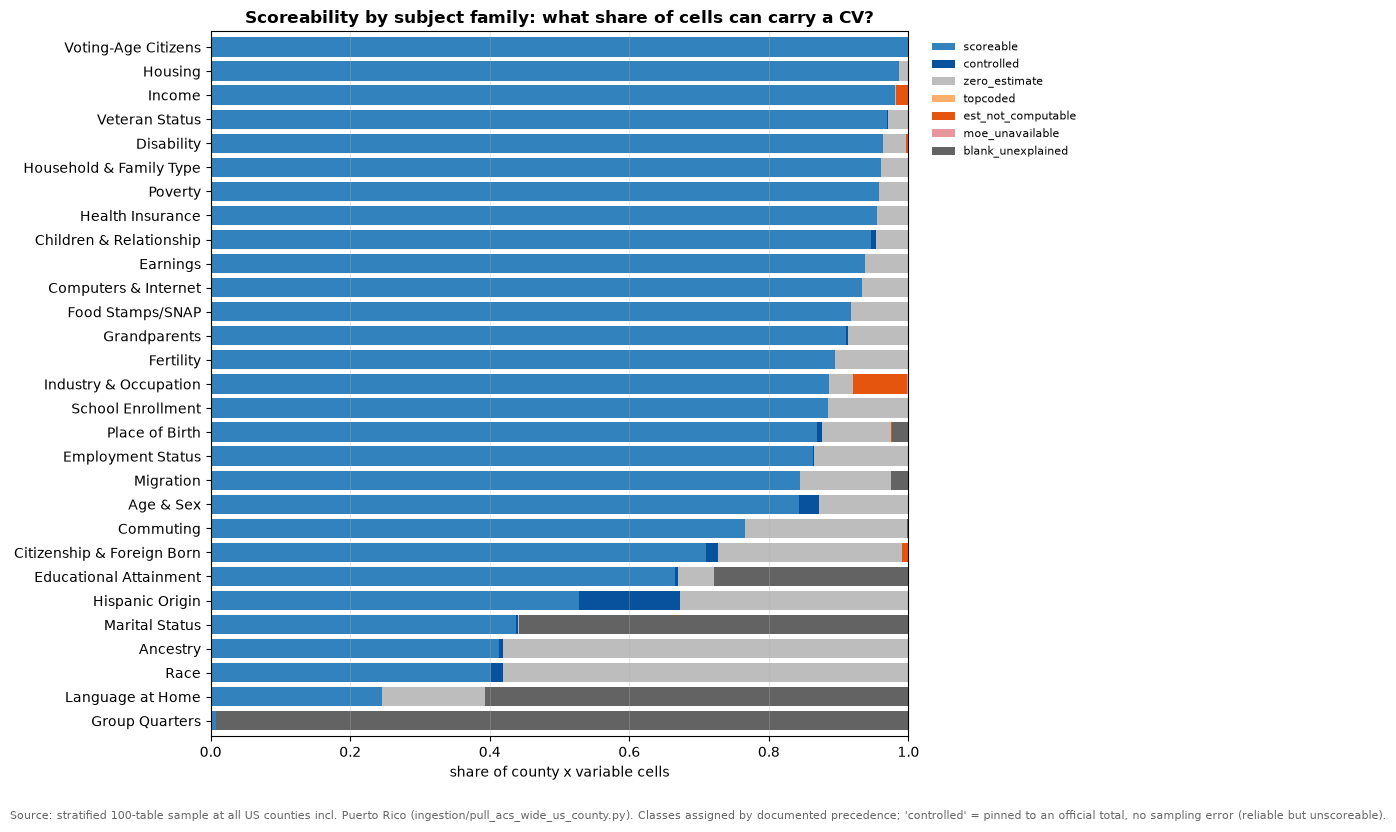

tables >95% blank at county scale: ['B12502', 'B12505', 'B15013', 'B16001', 'B26110', 'B26219']


scoreable share -- states+DC vs Puerto Rico:
is_pr
states+DC      0.723
Puerto Rico    0.537
overall scoreable share: 71.8%


In [6]:
shares = (df.groupby("family_name", observed=True)["cell_class"]
          .value_counts(normalize=True).unstack(fill_value=0.0))
order = ["scoreable", "controlled", "zero_estimate", "topcoded",
         "est_not_computable", "est_too_few_cases", "est_not_applicable",
         "moe_unavailable", "blank_unexplained", "other_blank_or_annotated"]
order = [c for c in order if c in shares.columns]
shares = shares[order].sort_values("scoreable")

colors = {"scoreable": "#3182bd", "controlled": "#08519c", "zero_estimate": "#bdbdbd",
          "topcoded": "#fdae6b", "est_not_computable": "#e6550d",
          "est_too_few_cases": "#a63603", "est_not_applicable": "#7b4173",
          "moe_unavailable": "#e7969c", "blank_unexplained": "#636363",
          "other_blank_or_annotated": "#d9d9d9"}
fig, ax = plt.subplots(figsize=(11, 8))
shares.plot.barh(stacked=True, ax=ax, color=[colors[c] for c in shares.columns],
                 width=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("share of county x variable cells")
ax.set_ylabel("")
ax.set_title("Scoreability by subject family: what share of cells can carry a CV?",
             fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
ax.grid(axis="x", alpha=0.3)
fig.text(0.01, -0.03,
         "Source: stratified 100-table sample at all US counties incl. Puerto Rico "
         "(ingestion/pull_acs_wide_us_county.py). Classes assigned by documented precedence; "
         "'controlled' = pinned to an official total, no sampling error (reliable but unscoreable).",
         fontsize=8, color="#666666")
fig.tight_layout()
out = PROCESSED / "eda14_scoreability_by_family.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

# Where do the silent blanks live? (Publication floors, quantified.)
blank_by_table = (df.assign(b=df["cell_class"] == "blank_unexplained")
                  .groupby("table_id", observed=True)["b"].mean())
fully_blank = blank_by_table[blank_by_table > 0.95].index.tolist()
print(f"tables >95% blank at county scale: {sorted(fully_blank)}")

# PR shown once: does keeping Puerto Rico change the story?
pr_split = (df.groupby("is_pr", observed=True)["cell_class"]
            .value_counts(normalize=True).unstack())
print("scoreable share -- states+DC vs Puerto Rico:")
print(pr_split["scoreable"].rename({False: "states+DC", True: "Puerto Rico"})
      .round(3).to_string())
overall_scoreable = float((df["cell_class"] == "scoreable").mean())
print(f"overall scoreable share: {overall_scoreable:.1%}")

**What the table says.** Scoreability is *structured by subject*, spanning nearly the
full range: **Group Quarters is ~1% scoreable** (its tables barely publish at county scale), Language at
Home ~25%, Race ~40% — while Housing (~99%), Income (~98%), Veteran Status and Disability (~96–97%) are
almost fully scoreable. **Six sampled tables are 100% blank at county scale** (detailed language B16001,
field-of-degree B15013, detailed marital B12502/B12505, group-quarters B26110/B26219) — the "silent nulls"
landmine (rows return, values don't) found at national scale: these tables have a *publication floor above
county*, and a tool must say "not published here," not "unreliable." Puerto Rico runs ~18 points less
scoreable than the states (54% vs 72%) — real, but not large enough to drive any family's ranking, so the
municipios stay in. And the blind-spot warning from EDA 05/06 recurs in new form: the classes are not
interchangeable, and *which* class dominates differs by family — absence has anatomy.

## 4. The flagship: CV distributions by subject family

For the scoreable cells only: how noisy is each subject area at county scale? The CV reference lines
0.12 / 0.30 / 0.40 follow ESRI's mapping convention and NCHS's reporting standard and are **shown
descriptively only** — this project's own reliability tiers are a deliberate later decision with the
Census mentors (project decision #8).

Chart saved to data\processed\eda14_cv_by_family.png (local-only, regenerable)


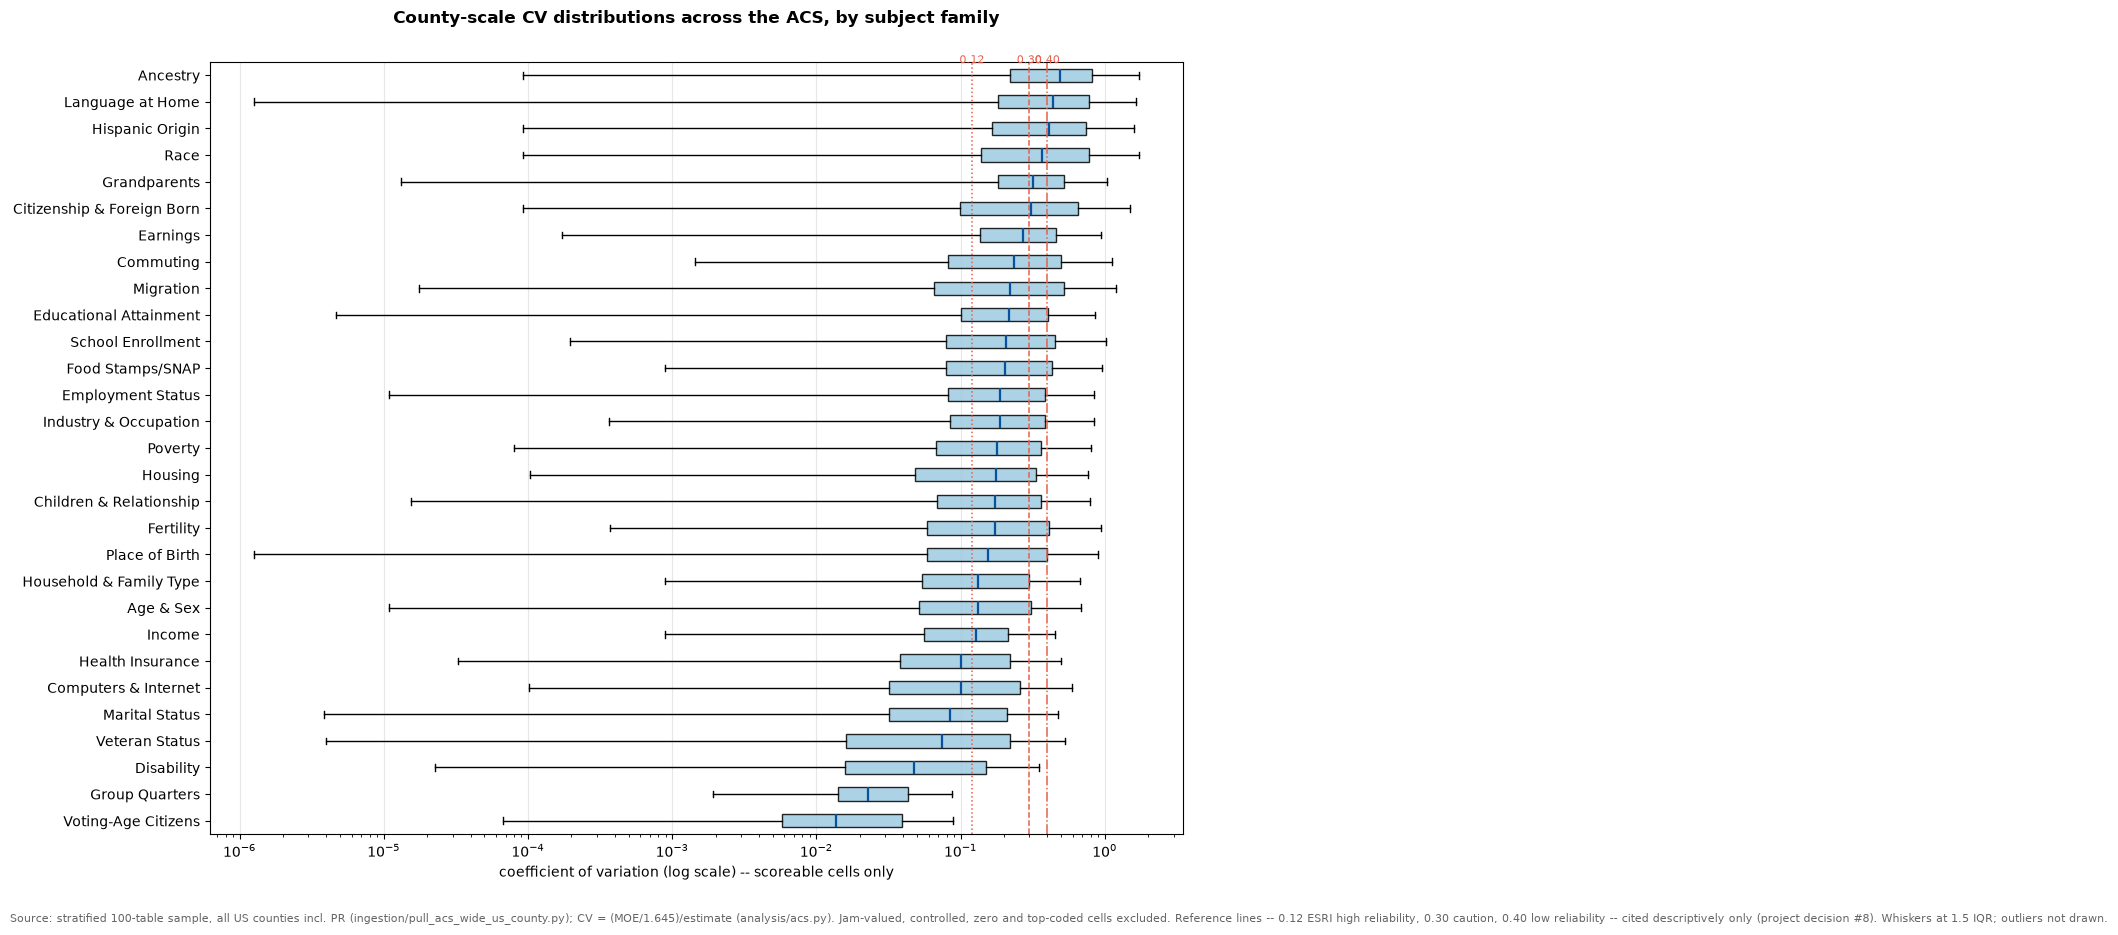

family median CVs span 0.014 (Voting-Age Citizens) to 0.491 (Ancestry) -- 36x
share of scoreable cells with CV > 0.30: 35.7%; CV <= 0.12: 37.6%


In [7]:
sc = df[df["cell_class"] == "scoreable"]
fam_order = (sc.groupby("family_name", observed=True)["cv"].median()
             .sort_values().index.tolist())
data = [sc.loc[sc["family_name"] == f, "cv"].dropna().values for f in fam_order]

fig, ax = plt.subplots(figsize=(12, 9))
bp = ax.boxplot(data, orientation="horizontal", tick_labels=fam_order, showfliers=False,
                patch_artist=True, medianprops={"color": "#08519c", "linewidth": 1.6})
for box in bp["boxes"]:
    box.set(facecolor="#9ecae1", alpha=0.85)
for x, style in ((0.12, ":"), (0.30, "--"), (0.40, "-.")):
    ax.axvline(x, linestyle=style, color="#e8604c", linewidth=1.1)
    ax.text(x, len(fam_order) + 0.45, f"{x:.2f}", fontsize=8,
            color="#e8604c", ha="center")
ax.set_xscale("log")
ax.set_xlabel("coefficient of variation (log scale) -- scoreable cells only")
ax.set_title("County-scale CV distributions across the ACS, by subject family",
             fontweight="bold", pad=28)
ax.grid(axis="x", alpha=0.3)
fig.text(0.01, -0.03,
         "Source: stratified 100-table sample, all US counties incl. PR "
         "(ingestion/pull_acs_wide_us_county.py); CV = (MOE/1.645)/estimate (analysis/acs.py). "
         "Jam-valued, controlled, zero and top-coded cells excluded. Reference lines -- 0.12 ESRI "
         "high reliability, 0.30 caution, 0.40 low reliability -- cited descriptively only "
         "(project decision #8). Whiskers at 1.5 IQR; outliers not drawn.",
         fontsize=8, color="#666666")
fig.tight_layout()
out = PROCESSED / "eda14_cv_by_family.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

fam_medians = sc.groupby("family_name", observed=True)["cv"].median().sort_values()
spread = fam_medians.iloc[-1] / fam_medians.iloc[0]
print(f"family median CVs span {fam_medians.iloc[0]:.3f} "
      f"({fam_medians.index[0]}) to {fam_medians.iloc[-1]:.3f} "
      f"({fam_medians.index[-1]}) -- {spread:,.0f}x")
print(f"share of scoreable cells with CV > 0.30: {(sc['cv'] > 0.30).mean():.1%}; "
      f"CV <= 0.12: {(sc['cv'] <= 0.12).mean():.1%}")
assert spread >= 10, (
    "family median CVs span less than one order of magnitude -- inconsistent with "
    "everything Phase 1 measured; check the classification")

**What the table says.** Even at the ACS's *most reliable* geography, subject families
are not remotely interchangeable: median CVs span **36×**, from Voting-Age Citizens (0.014) and Group
Quarters' few published totals (0.023) up through Income (0.128) and Poverty (0.178) to Race (0.37),
Hispanic Origin (0.41), Language (0.44) and Ancestry (**0.49** — the median *Ancestry* cell's noise is half
the size of its estimate). Overall, **36% of scoreable county-scale cells exceed the 0.30 caution
convention** — county scale does not make detail safe; it makes *totals* safe. The pattern is the EDA 02/03
mechanism at catalog width: families whose tables slice populations finely (ancestry, language, race
iterations) live beyond the caution line even in large geographies. For the tool, subject-level defaults are
untenable — reliability must be judged per estimate, which is the composite score's core premise (Q2).

## 5. Does the −0.5 size law hold dataset-wide?

EDA 02 established (on nine NJ variables) that **count** CVs fall with estimate size along the theoretical
−0.5 sampling-noise slope. EDA 07 showed **medians** escape the law — and warned that a median's dollar
*value* is not sample support ("income size is households, not dollars"). Here both claims meet ~3,000
variables: counts get the pooled log-log fit; medians get the honest version — the fit **within each median
table**, because pooling rent (~$1k), income (~$60k) and home values (~$200k) manufactures a between-table
correlation that has nothing to do with sampling.

Chart saved to data\processed\eda14_cv_vs_size.png (local-only, regenerable)


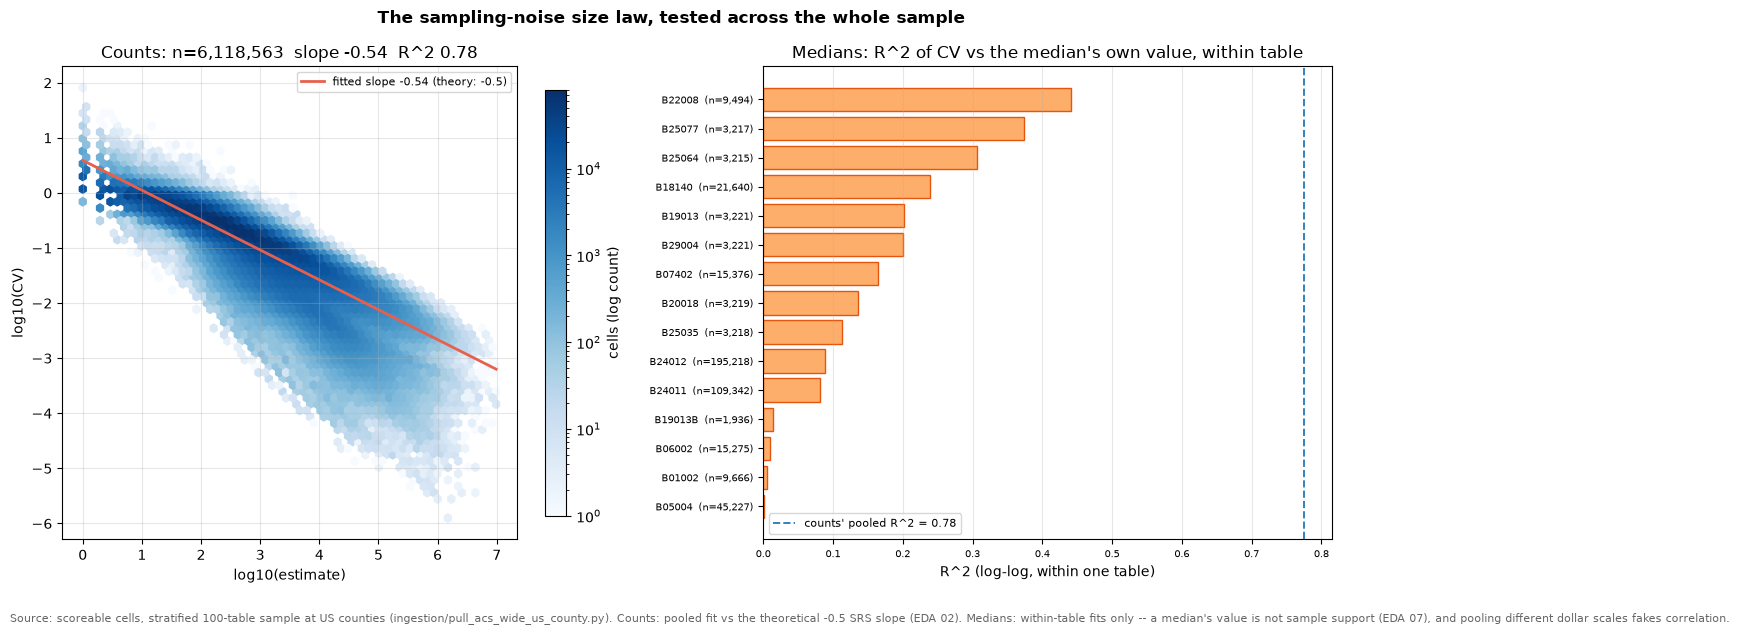

counts: slope -0.542, R^2 0.776 (n=6,118,563)
medians: pooled R^2 0.122; within-table R^2 range 0.001-0.441 (median 0.136)


In [8]:
fit = sc[(sc["estimate"] > 0) & (sc["cv"] > 0)].copy()
fit["lx"] = np.log10(fit["estimate"])
fit["ly"] = np.log10(fit["cv"])

counts = fit[fit["measurement_type"] == "count"]
medians = fit[fit["measurement_type"] == "median"]

slope_c, intercept_c = np.polyfit(counts["lx"], counts["ly"], 1)
r2_c = np.corrcoef(counts["lx"], counts["ly"])[0, 1] ** 2
r2_m_pooled = np.corrcoef(medians["lx"], medians["ly"])[0, 1] ** 2

# Within-table fits for every median table with enough scoreable cells.
within = {}
for t, sub in medians.groupby("table_id", observed=True):
    if len(sub) >= 500:
        within[t] = np.corrcoef(sub["lx"], sub["ly"])[0, 1] ** 2
within = pd.Series(within).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
hb = axes[0].hexbin(counts["lx"], counts["ly"], gridsize=60, bins="log", cmap="Blues")
xs = np.array([counts["lx"].min(), counts["lx"].max()])
axes[0].plot(xs, slope_c * xs + intercept_c, color="#e8604c", linewidth=2,
             label=f"fitted slope {slope_c:.2f} (theory: -0.5)")
axes[0].set_title(f"Counts: n={len(counts):,}  slope {slope_c:.2f}  R^2 {r2_c:.2f}")
axes[0].set_xlabel("log10(estimate)")
axes[0].set_ylabel("log10(CV)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0], shrink=0.9, label="cells (log count)")

axes[1].barh([f"{t}  (n={len(medians[medians['table_id'] == t]):,})" for t in within.index],
             within.values, color="#fdae6b", edgecolor="#e6550d")
axes[1].axvline(r2_c, color="#3182bd", linestyle="--", linewidth=1.4,
                label=f"counts' pooled R^2 = {r2_c:.2f}")
axes[1].set_title("Medians: R^2 of CV vs the median's own value, within table")
axes[1].set_xlabel("R^2 (log-log, within one table)")
axes[1].tick_params(labelsize=7.5)
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)
fig.suptitle("The sampling-noise size law, tested across the whole sample",
             fontweight="bold")
fig.tight_layout()
fig.text(0.01, -0.04,
         "Source: scoreable cells, stratified 100-table sample at US counties "
         "(ingestion/pull_acs_wide_us_county.py). Counts: pooled fit vs the theoretical -0.5 "
         "SRS slope (EDA 02). Medians: within-table fits only -- a median's value is not "
         "sample support (EDA 07), and pooling different dollar scales fakes correlation.",
         fontsize=8, color="#666666")
out = PROCESSED / "eda14_cv_vs_size.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

print(f"counts: slope {slope_c:.3f}, R^2 {r2_c:.3f} (n={len(counts):,})")
print(f"medians: pooled R^2 {r2_m_pooled:.3f}; within-table R^2 range "
      f"{within.min():.3f}-{within.max():.3f} (median {within.median():.3f})")

assert -0.7 <= slope_c <= -0.3, (
    f"count slope {slope_c:.2f} is far from the -0.5 sampling law -- EDA 02's central "
    "mechanism should reproduce at national county scale")
assert r2_c >= 0.5, (
    f"count R^2 {r2_c:.2f} < 0.5 -- estimate size should dominate count CVs (EDA 07)")
assert r2_m_pooled < 0.2, (
    f"pooled median R^2 {r2_m_pooled:.2f} >= 0.2 -- medians should not follow a size "
    "law on their own dollar values")
for t in ("B01002", "B05004", "B19013B"):
    if t in within.index:
        assert within[t] < 0.05, (
            f"{t} within-table R^2 {within[t]:.3f} >= 0.05 -- the EDA 07 escape "
            "should reproduce for demographic medians")
assert within.max() < 0.55, (
    f"a median table reached within-table R^2 {within.max():.2f} -- approaching "
    "count-like behavior, which would contradict the value-is-not-size premise")

**What the table says.** The count law generalizes emphatically: across ~6.1M cells
and every subject family, the pooled slope is **−0.54 with R² ≈ 0.78** — one line, learned on nine NJ
variables, predicts most count-CV variation across the entire sampled catalog. That makes estimate size a
*free, strong* reliability predictor for ~81% of ACS variables (Q2's cheapest component). Medians tell the
subtler story: **pooled** R² is only ~0.12, and within-table the fits are heterogeneous — demographic
medians (median age B01002, nativity B05004, the B19013B income iteration) sit at R² ≤ 0.01, exactly EDA
07's escape, while housing and earnings medians (home value 0.37, rent 0.31, B22008 0.44) show moderate
correlation. That correlation is *not* a size law — a median's value is not its sample — it is geography
arriving sideways (expensive-housing counties are metropolitan and populous). The design consequence
stands: medians need universe-based treatment (EDA 07's approach), never value-based.

## 6. Table-level reliability profile — the curated-list seed

If the tool expands beyond income & poverty, which tables could it *responsibly* show at county scale?
We rank each sampled table by its share of **usable-without-caution** cells — scoreable with CV ≤ 0.30
*plus* controlled cells (which have no sampling error at all). Counting controlled cells as usable matters:
by raw "scoreable share" the single most reliable table in the ACS (total population, pinned to official
totals) would rank *last*, which is exactly the blank-MOE misreading this project exists to fix. The 0.30
line is the descriptive convention (decision #8), not our tier.

Chart saved to data\processed\eda14_table_reliability_rank.png (local-only, regenerable)


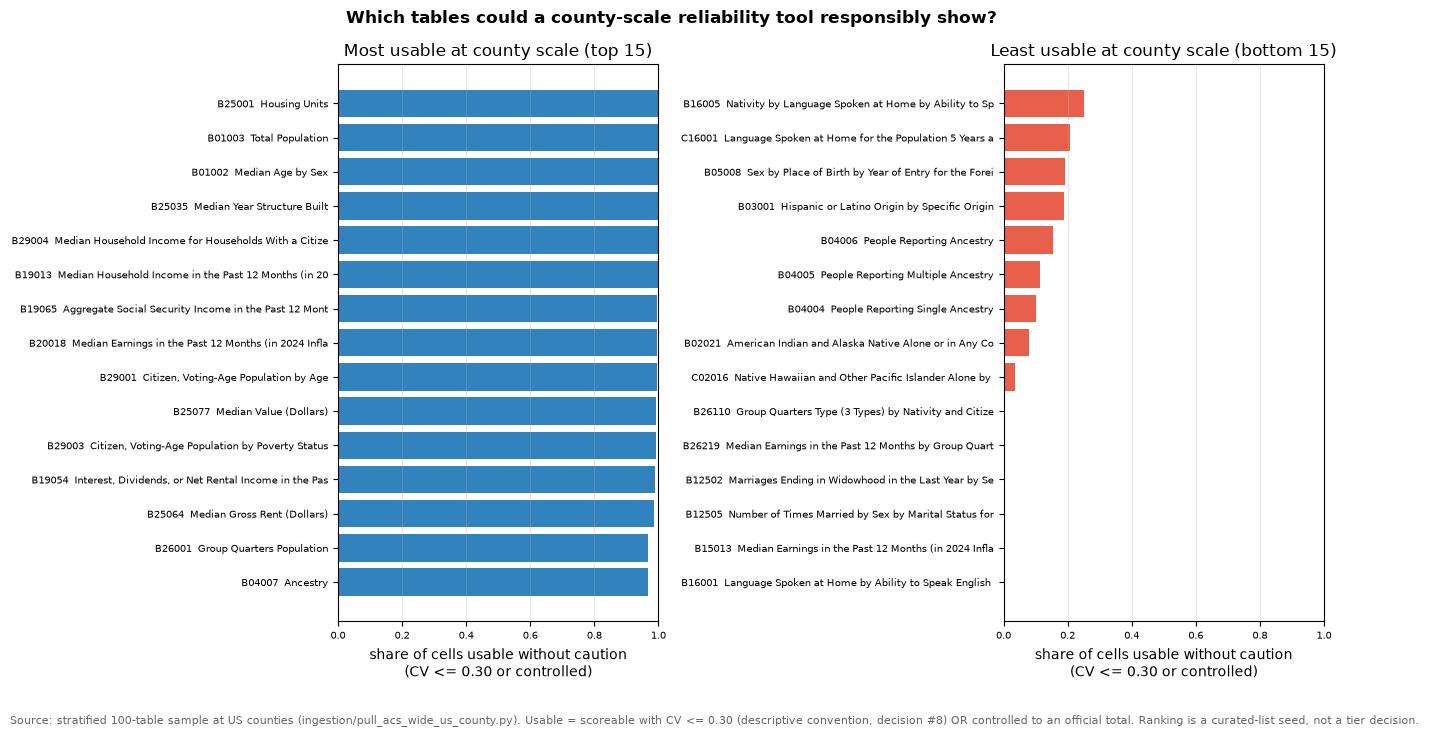

bottom-15 diagnosis (unpublished vs published-but-noisy):
          usable  blank_share
table_id                     
B16001     0.000          1.0
B15013     0.000          1.0
B12505     0.000          1.0
B12502     0.000          1.0
B26219     0.000          1.0
B26110     0.000          1.0
C02016     0.034          0.0
B02021     0.079          0.0
B04004     0.100          0.0
B04005     0.114          0.0
B04006     0.153          0.0
B03001     0.190          0.0
B05008     0.192          0.0
C16001     0.207          0.0
B16005     0.251          0.0
B01003 usable share 99.9% (pct 100%); B19013B 47.3% (pct 27%)


In [9]:
usable = (df["cell_class"].eq("controlled")
          | (df["cell_class"].eq("scoreable") & df["cv"].le(0.30)))
rank = (pd.DataFrame({"table_id": df["table_id"], "usable": usable})
        .groupby("table_id", observed=True)["usable"].mean().sort_values())
titles = (manifest[manifest["is_estimate"]]
          .drop_duplicates("table_id").set_index("table_id")["table_title_raw"])

def _label(t):
    title = str(titles.get(t, ""))[:52]
    return f"{t}  {title}"

top15, bottom15 = rank.tail(15), rank.head(15)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 7))
axes[0].barh([_label(t) for t in top15.index], top15.values, color="#3182bd")
axes[0].set_title("Most usable at county scale (top 15)")
axes[1].barh([_label(t) for t in bottom15.index], bottom15.values, color="#e8604c")
axes[1].set_title("Least usable at county scale (bottom 15)")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel("share of cells usable without caution\n(CV <= 0.30 or controlled)")
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=7.5)
fig.suptitle("Which tables could a county-scale reliability tool responsibly show?",
             fontweight="bold")
fig.tight_layout()
fig.text(0.01, -0.04,
         "Source: stratified 100-table sample at US counties "
         "(ingestion/pull_acs_wide_us_county.py). Usable = scoreable with CV <= 0.30 "
         "(descriptive convention, decision #8) OR controlled to an official total. "
         "Ranking is a curated-list seed, not a tier decision.",
         fontsize=8, color="#666666")
out = PROCESSED / "eda14_table_reliability_rank.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

# The bottom of the ranking mixes two failure modes -- disentangle them.
blank_share = (df.assign(b=df["cell_class"] == "blank_unexplained")
               .groupby("table_id", observed=True)["b"].mean())
bottom_diag = pd.DataFrame({"usable": rank.head(15),
                            "blank_share": blank_share[rank.head(15).index]}).round(3)
print("bottom-15 diagnosis (unpublished vs published-but-noisy):")
print(bottom_diag.to_string())

pct_b01003 = float(rank.rank(pct=True).get("B01003", np.nan))
pct_b19013b = float(rank.rank(pct=True).get("B19013B", np.nan))
assert pct_b01003 >= 0.9, (
    f"B01003 (controlled total population) ranks at the {pct_b01003:.0%} percentile -- "
    "it should be near the top once controlled cells count as usable")
assert pct_b19013b <= 0.5, (
    f"B19013B (median income, Black householder) ranks at the {pct_b19013b:.0%} "
    "percentile -- median x small subgroup should sit in the lower half")
print(f"B01003 usable share {rank.get('B01003'):.1%} (pct {pct_b01003:.0%}); "
      f"B19013B {rank.get('B19013B'):.1%} (pct {pct_b19013b:.0%})")

**What the table says.** The top of the ranking is headline material for a curated
list: housing-unit and household totals, median age, median household income, year-built medians and total
population are ~99–100% usable at county scale. The bottom is just as instructive, but for **two different
reasons the diagnosis table separates**: six tables sit at 0% because they are *unpublished* at county
scale (blank_share ≈ 1.0 — a floor problem), while the others (detailed race C02016/B02021, language
C16001) are published but drown in small-cell noise (blank_share ≈ 0 — a sampling problem). A tool must
never present those two zeros the same way. The anchors behaved as theory demands: B01003 lands at the
99.5th percentile *only because* controlled cells count as usable — and B19013B (median income, Black
householder) lands in the bottom third, the median × small-subgroup double penalty made visible.

## 7. Ground truth: the new pull must reproduce our verified numbers

A survey pipeline this generic earns trust the same way every pull in this repo has: by reproducing
hand-verified receipts exactly. The 21 New Jersey counties' median household income (estimate AND margin
of error) must match `pull_acs_income_county_nj.py`'s verified vintage-2024 rows to the dollar, and the
CVs must agree with `analysis/acs.py`'s shared formula. A second check against the original Phase 1 NJ
pull also demonstrates the censusdis contrast this script exists to avoid.

In [10]:
comp = load_parquet("acs5_nj_county_income_2019_2024.parquet",
                    "pull_acs_income_county_nj.py")
comp = comp[comp["VINTAGE"] == 2024].copy()
comp["geoid"] = comp["STATE"] + comp["COUNTY"]

mine = df[(df["variable"] == "B19013_001")
          & df["geoid"].astype(str).str.startswith("34")].copy()
mine["geoid"] = mine["geoid"].astype(str)
merged = comp.merge(mine[["geoid", "estimate", "cv", "cell_class"]], on="geoid",
                    validate="1:1")
assert len(merged) == 21, f"expected 21 NJ counties in both pulls, got {len(merged)}"

scoreable_nj = merged[merged["cell_class"] == "scoreable"]
assert bool((scoreable_nj["estimate"] == scoreable_nj["B19013_001E"]).all()), (
    "survey B19013 estimates differ from the verified NJ pull")
cv_comp = acs.cv(merged["B19013_001E"], merged["B19013_001M"])
assert bool(np.allclose(scoreable_nj["cv"],
                        cv_comp[merged["cell_class"] == "scoreable"], rtol=1e-9)), (
    "survey CVs differ from analysis.acs.cv on the verified pull")
print(f"{len(scoreable_nj)}/21 NJ counties scoreable; estimates match exactly; "
      f"CVs agree with analysis/acs.py to machine precision")
print(f"non-scoreable NJ classes: "
      f"{merged.loc[merged['cell_class'] != 'scoreable', 'cell_class'].tolist() or 'none'}")

# Secondary check + the censusdis contrast, on the original Phase 1 pull.
nj0 = load_parquet("acs5_2024_nj_county.parquet", "pull_acs_nj.py")
nj0["geoid"] = nj0["STATE"] + nj0["COUNTY"]
pov = df[(df["variable"] == "B17001_002")
         & df["geoid"].astype(str).str.startswith("34")].copy()
pov["geoid"] = pov["geoid"].astype(str)
m2 = nj0.merge(pov[["geoid", "estimate"]], on="geoid", validate="1:1")
assert (m2["B17001_002E"] == m2["estimate"]).all(), (
    "survey poverty counts differ from the Phase 1 NJ pull")

pop = df[(df["variable"] == "B01003_001") & df["geoid"].astype(str).str.startswith("34")]
print(f"\nThe censusdis contrast, live: Phase 1's censusdis pull stores NJ county "
      f"population MOEs as NaN ({int(nj0['B01003_001M'].isna().sum())}/21 blank), "
      f"while this pull preserves the sentinel: "
      f"{int((pop['cell_class'] == 'controlled').sum())}/21 counties classed "
      f"'controlled' -- reliable, not missing.")

# National footnote to the same phenomenon: counties whose population MOE
# is NOT the controlled sentinel -- a real published MOE instead.
pop_us = df[df["variable"] == "B01003_001"]
notc = pop_us[pop_us["cell_class"] != "controlled"]
print(f"\nNational footnote: {len(notc)} of {len(pop_us):,} counties publish a REAL "
      f"population MOE instead of the controlled sentinel "
      f"(top states: {notc['geoid'].astype(str).str[:2].value_counts().head(4).to_dict()}; "
      f"all {notc['cell_class'].value_counts().to_dict()}). The national echo of the "
      f"131-NJ-tract mystery from EDA 02 -- characterized, not explained; mentor question.")

21/21 NJ counties scoreable; estimates match exactly; CVs agree with analysis/acs.py to machine precision
non-scoreable NJ classes: none



The censusdis contrast, live: Phase 1's censusdis pull stores NJ county population MOEs as NaN (21/21 blank), while this pull preserves the sentinel: 21/21 counties classed 'controlled' -- reliable, not missing.

National footnote: 132 of 3,222 counties publish a REAL population MOE instead of the controlled sentinel (top states: {'48': 28, '31': 26, '46': 14, '30': 13}; all {'scoreable': 132, 'controlled': 0, 'blank_unexplained': 0, 'est_not_computable': 0, 'moe_unavailable': 0, 'topcoded': 0, 'zero_estimate': 0}). The national echo of the 131-NJ-tract mystery from EDA 02 -- characterized, not explained; mentor question.


**What the table says.** The generic pipeline reproduces the hand-verified numbers
exactly — all 21 NJ counties match the dedicated income pull to the dollar on both estimate and MOE, and
the CVs agree with the shared formula to machine precision. The censusdis contrast is now demonstrated
live in one dataset: the same 21 county population MOEs that Phase 1 stored as *blank* arrive here as the
controlled sentinel — "extremely reliable," not "missing." And the survey surfaced a national curiosity we
already met in miniature: **132 counties** (concentrated in Texas, Nebraska, South Dakota, Montana, Kansas,
North Dakota — rural plains) publish a *real* population MOE where every other county is controlled. Same
shape as EDA 02's 131 NJ tracts with near-controlled MOEs. Characterize, don't guess: logged as a mentor
question.

## Findings

**What did we find?**

1. **~72% of the sampled ACS surface can carry an error bar; the other 28% is structured absence.**
   Zero estimates (16%), silent publication floors (11% — six of 100 tables publish nothing at county
   scale), controlled estimates (0.6%, the *most* reliable cells), jam values (~0.5%), edge-coded medians
   and top-codes (slivers). Each class needs different words in any user-facing tool.
2. **Subject families differ by 36× in median CV even at county scale** — Voting-Age Citizens 0.014 →
   Ancestry 0.49 — and **36% of scoreable cells exceed the 0.30 caution convention**. County scale
   protects totals, not detail; fine population slices are noisy everywhere.
3. **The count size law generalizes**: pooled slope −0.54, R² ≈ 0.78 across ~6.1M cells — EDA 02's
   nine-variable NJ finding holds across the catalog, making estimate size a free reliability predictor
   for ~81% of variables. **Medians escape it within-table** (demographic medians R² ≤ 0.01, EDA 07
   reproduced); housing/earnings medians' moderate correlations are geography confounds, not size laws.
4. **The metadata and encoding landscape has landmines a tool must survive**: MOE names absent from
   variables.json (re-verified); jam values spelled two ways (integer vs float — string matching silently
   loses ~3,900 cells); annotation columns doubling as empirical top/bottom-code markers; and 132 rural
   counties publishing real population MOEs where the rest of the country is controlled (the national echo
   of EDA 02's 131-tract mystery — mentor question, not guessed at).

**Why does it matter to the Census Bureau?** The proof of concept says the expansion is *viable*: one
generic, verified pipeline can classify and score the whole detailed-table surface, and reliability
structure (which families, which table types, which encodings) is learnable and communicable. But it also
says a CV-only tool would misdescribe both ends of the reliability spectrum — the controlled best and the
jammed/blank worst — so the class taxonomy, not just the score, is part of honest communication (Q4).

**What should we do next?** (1) Put the scope expansion and this survey in front of the mentors (the
standing scoped-stack question gets an addendum). (2) If adopted: graduate the manifest/classification
logic into `analysis/`, use the Section 6 ranking to draft the curated table list, and extend the survey
to tract scale for the shortlisted tables (where EDA 01 says the story sharpens). (3) EDA 11 (tier
stability across vintages) remains owed for the income/poverty anchor. (4) Add the 132-county MOE
curiosity to the mentor-question list.

**Charts saved** (all `data/processed/`, local-only, regenerable): `eda14_metadata_census.png`,
`eda14_scoreability_by_family.png`, `eda14_cv_by_family.png`, `eda14_cv_vs_size.png`,
`eda14_table_reliability_rank.png`.